In [54]:
# Allow PIL to open truncated images (avoid OSError: image file is truncated)
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


In [55]:
import os
import math
import time
import random
from typing import Tuple, Dict, List

import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import transforms

import os
import math
import time
import random
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [56]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = False   # переключите на True для частичного датасета и более быстрого обучения
DATA_DIR = "./data"

BATCH_SIZE = 128
EPOCHS = 4 if FAST_MODE else 12

Device: cpu


In [57]:
STL10_MEAN = (0.4467, 0.4398, 0.4067)
STL10_STD = (0.2242, 0.2215, 0.2239)

def load_stl10(data_dir: str = DATA_DIR, tf_train = None):

    tf_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])

    ds_train_full = torchvision.datasets.STL10(root=data_dir, download=True, transform=tf_train)
    ds_test = torchvision.datasets.STL10(root=data_dir, download=True, transform=tf_test)

    return ds_train_full, ds_test



In [59]:
tf_train1 = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])
ds_train_full1, ds_test1 = load_stl10(tf_train=tf_train1)
class_names = ds_train_full1.classes

print("Train full:", len(ds_train_full1))
print("Test:", len(ds_test1))
print("Classes:", class_names)

Train full: 5000
Test: 5000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [60]:
tf_train2 = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])
ds_train_full2, ds_test2 = load_stl10(tf_train=tf_train2)
class_names = ds_train_full2.classes

print("Train full:", len(ds_train_full2))
print("Test:", len(ds_test2))
print("Classes:", class_names)

Train full: 5000
Test: 5000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [61]:
def make_loaders(
    ds_train_full,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    # train/val split
    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    ds_train, ds_val = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )

    # FAST_MODE: уменьшаем размер для скорости
    if fast_mode:
        # аккуратно: Subset от Subset (random_split возвращает Subset)
        rng = np.random.RandomState(seed)
        train_idx = rng.choice(len(ds_train), size=min(6000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(1500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(1500, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test_small = Subset(ds_test, test_idx)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(ds_train_full1, ds_test1)
batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)
train_loader2, val_loader2, test_loader2 = make_loaders(ds_train_full2, ds_test2)
batch = next(iter(train_loader2))
x2, y2 = batch
print("x:", x2.shape, x2.dtype)
print("y:", y2.shape, y2.dtype)

c:\Users\Пётр\Desktop\IAIapp\IAI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


x: torch.Size([128, 3, 96, 96]) torch.float32
y: torch.Size([128]) torch.int64
x: torch.Size([128, 3, 96, 96]) torch.float32
y: torch.Size([128]) torch.int64


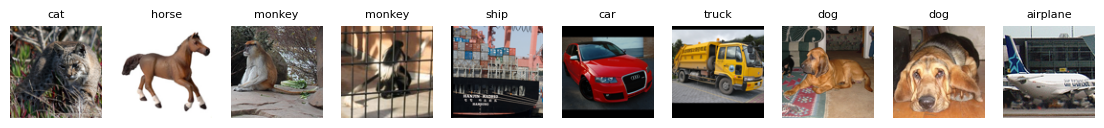

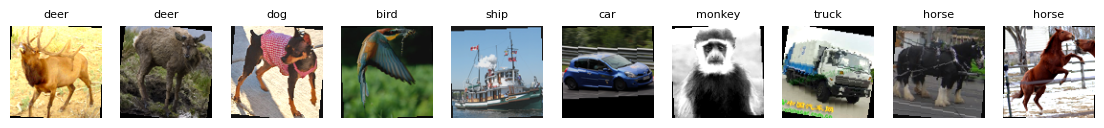

In [62]:
def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)
show_images(train_loader2, n=10)

In [63]:
NUM_CLASSES = 10


class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32 -> 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16x16 -> 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 8x8 -> 8x8
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x
    
    
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)



cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Trainable params: 4814666


In [64]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

In [65]:
criterion = nn.CrossEntropyLoss()


exp_id = "CNN1_simple"
lr = 1e-3
weight_decay = 0.0
model = SimpleCNN(NUM_CLASSES)
epochs = EPOCHS
model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0)
print("\n" + "=" * 80)
print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
print("Trainable params:", count_params(model))
hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
plot_history(hist, title="Simple CNN")
# Сохранение результатов и модели (C1)
import os, json, pandas as pd
os.makedirs('./artifacts', exist_ok=True)
model_path = f'./artifacts/best_classifier_C1.pt'
torch.save(model.state_dict(), model_path)
config = {"dataset": "STL10", "seed": int(RANDOM_STATE), "model_summary": "SimpleCNN", "optimizer": "Adam", "lr": lr, "epochs_trained": int(epochs), "best_val_accuracy": float(best_val_acc)}
with open(f'./artifacts/best_classifier_config_C1.json', 'w') as f: json.dump(config, f, indent=2)
runs_path = './artifacts/runs.csv'
row = { 'experiment_id': 'C1', 'task': 'classification', 'dataset': 'STL10', 'seed': int(RANDOM_STATE), 'model_summary': 'SimpleCNN', 'optimizer': 'Adam', 'lr': lr, 'epochs_trained': int(epochs), 'best_val_accuracy': float(best_val_acc), 'precision': '', 'recall': '', 'mean_iou': '', 'notes': '' }
if os.path.exists(runs_path):
    df_runs = pd.read_csv(runs_path)
    df_runs = df_runs[df_runs['experiment_id'] != 'C1']  # remove previous C1 if present
    df_runs = pd.concat([df_runs, pd.DataFrame([row])], ignore_index=True)
else:
    df_runs = pd.DataFrame([row])
df_runs.to_csv(runs_path, index=False)
print('Saved model to', model_path, 'and updated', runs_path)


Experiment CNN1_simple | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 4814666
Epoch 01/12 | train loss 1.9320, acc 0.289 | val loss 1.7677, acc 0.345 | 42.9s
Epoch 02/12 | train loss 1.5084, acc 0.442 | val loss 1.5510, acc 0.421 | 41.9s
Epoch 03/12 | train loss 1.3196, acc 0.516 | val loss 1.5187, acc 0.462 | 41.5s
Epoch 04/12 | train loss 1.1318, acc 0.588 | val loss 1.2868, acc 0.537 | 41.0s
Epoch 05/12 | train loss 0.9377, acc 0.670 | val loss 1.2891, acc 0.558 | 40.5s
Epoch 06/12 | train loss 0.7473, acc 0.731 | val loss 1.3066, acc 0.548 | 42.5s
Epoch 07/12 | train loss 0.5683, acc 0.804 | val loss 1.4077, acc 0.557 | 43.8s
Epoch 08/12 | train loss 0.3615, acc 0.887 | val loss 1.5318, acc 0.588 | 44.7s


KeyboardInterrupt: 


Experiment CNN2_simple | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 4814666


c:\Users\Пётр\Desktop\IAIapp\IAI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/12 | train loss 2.0576, acc 0.242 | val loss 1.7116, acc 0.366 | 42.5s
Epoch 02/12 | train loss 1.5885, acc 0.414 | val loss 1.5908, acc 0.384 | 42.0s
Epoch 03/12 | train loss 1.4003, acc 0.485 | val loss 1.3874, acc 0.479 | 43.0s
Epoch 04/12 | train loss 1.2880, acc 0.539 | val loss 1.3467, acc 0.528 | 43.2s
Epoch 05/12 | train loss 1.1631, acc 0.574 | val loss 1.2907, acc 0.537 | 43.0s
Epoch 06/12 | train loss 1.0740, acc 0.610 | val loss 1.2710, acc 0.542 | 43.1s
Epoch 07/12 | train loss 0.9961, acc 0.645 | val loss 1.2121, acc 0.554 | 42.9s
Epoch 08/12 | train loss 0.9258, acc 0.672 | val loss 1.2305, acc 0.595 | 43.1s
Epoch 09/12 | train loss 0.8323, acc 0.704 | val loss 1.1866, acc 0.563 | 41.2s
Epoch 10/12 | train loss 0.7769, acc 0.736 | val loss 1.2244, acc 0.587 | 41.3s
Epoch 11/12 | train loss 0.7424, acc 0.731 | val loss 1.2264, acc 0.593 | 40.8s
Epoch 12/12 | train loss 0.6532, acc 0.773 | val loss 1.3074, acc 0.584 | 41.3s


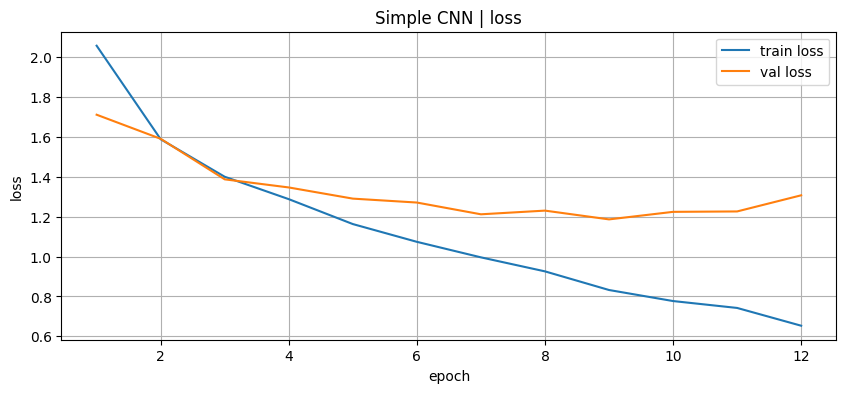

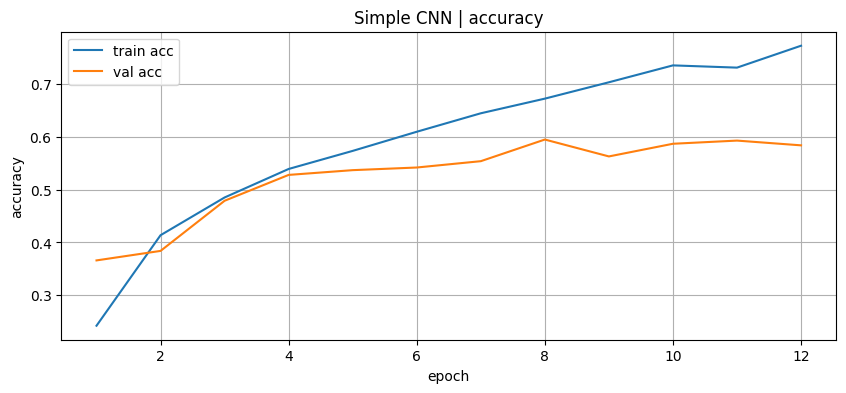

Saved model to ./artifacts/best_classifier_C2.pt and updated ./artifacts/runs.csv


In [ ]:
criterion = nn.CrossEntropyLoss()


exp_id = "CNN2_simple"
lr = 1e-3
weight_decay = 0.0
model = SimpleCNN(NUM_CLASSES)
epochs = EPOCHS
model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0)
print("\n" + "=" * 80)
print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
print("Trainable params:", count_params(model))
hist = fit(model, train_loader2, val_loader2, optimizer, criterion, epochs=epochs, verbose=True)
best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
plot_history(hist, title="Simple CNN")
# Сохранение результатов и модели (C2)
import os, json, pandas as pd
os.makedirs('./artifacts', exist_ok=True)
model_path = f'./artifacts/best_classifier_C2.pt'
torch.save(model.state_dict(), model_path)
config = {"dataset": "STL10", "seed": int(RANDOM_STATE), "model_summary": "SimpleCNN-aug", "optimizer": "Adam", "lr": lr, "epochs_trained": int(epochs), "best_val_accuracy": float(best_val_acc)}
with open(f'./artifacts/best_classifier_config_C2.json', 'w') as f: json.dump(config, f, indent=2)
runs_path = './artifacts/runs.csv'
row = { 'experiment_id': 'C2', 'task': 'classification', 'dataset': 'STL10', 'seed': int(RANDOM_STATE), 'model_summary': 'SimpleCNN-aug', 'optimizer': 'Adam', 'lr': lr, 'epochs_trained': int(epochs), 'best_val_accuracy': float(best_val_acc), 'precision': '', 'recall': '', 'mean_iou': '', 'notes': '' }
if os.path.exists(runs_path):
    df_runs = pd.read_csv(runs_path)
    df_runs = df_runs[df_runs['experiment_id'] != 'C2']  # remove previous C2 if present
    df_runs = pd.concat([df_runs, pd.DataFrame([row])], ignore_index=True)
else:
    df_runs = pd.DataFrame([row])
df_runs.to_csv(runs_path, index=False)
print('Saved model to', model_path, 'and updated', runs_path)

In [66]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = True
DATA_DIR = "./data"

BATCH_SIZE = 64  # ResNet тяжелее, чем SimpleCNN
EPOCHS_HEAD = 3 if FAST_MODE else 8
EPOCHS_FT   = 3 if FAST_MODE else 8
     

Device: cpu


In [67]:

def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [68]:
# mean/std для нормализации (если weights=None – используем стандартные ImageNet)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Для CIFAR-10 придётся изменить размер (ResNet обычно ожидает ~224x224).
# Чтобы было быстрее, можно выбрать размер 160 или 192. Оставим 224 как стандарт.
IMG_SIZE = 224

# Если доступны предобученные веса -- используем их трансформации/mean/std для препроцессинга
if weights is not None:
    try:
        eval_tf = weights.transforms()  # рекомендуемый препроцессинг для evaluation
        mean = tuple(weights.meta.get("mean", IMAGENET_MEAN))
        std = tuple(weights.meta.get("std", IMAGENET_STD))
    except Exception as e:
        print("weights.transforms() недоступен, используем стандартную нормализацию. Причина:", repr(e))
        mean, std = IMAGENET_MEAN, IMAGENET_STD
        eval_tf = transforms.Compose([
            transforms.Resize(IMG_SIZE + 32),
            transforms.CenterCrop(IMG_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
else:
    mean, std = IMAGENET_MEAN, IMAGENET_STD
    eval_tf = transforms.Compose([
        transforms.Resize(IMG_SIZE + 32),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

# Train transforms: оставляем аугментации, но нормализацию берем из весов если есть
train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

def load_cifar10_tl(data_dir: str = DATA_DIR):
    # Важно: для train нужны аугментации, для val/test – детерминированные transforms.
    # Поэтому создаём ДВА варианта train-датасета с разными transforms и будем делить по одним и тем же индексам.
    ds_train_aug  = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=train_tf)
    ds_train_eval = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=eval_tf)
    ds_test       = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=True, transform=eval_tf)
    return ds_train_aug, ds_train_eval, ds_test

ds_train_aug, ds_train_eval, ds_test = load_cifar10_tl()
class_names = ds_train_aug.classes
print("Train full:", len(ds_train_aug))
print("Test:", len(ds_test))

c:\Users\Пётр\Desktop\IAIapp\IAI\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train full: 50000
Test: 10000


In [69]:
def make_loaders_tl(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    # Deterministic split using torch.Generator to ensure reproducible indices
    gen = torch.Generator()
    gen.manual_seed(int(seed))
    indices = torch.randperm(n_total, generator=gen).tolist()

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        # Subsampling also deterministic (different generator state)
        gen2 = torch.Generator()
        gen2.manual_seed(int(seed) + 1)
        k_train = min(4000, len(ds_train))
        k_val = min(1000, len(ds_val))
        k_test = min(1000, len(ds_test))

        train_idx2 = torch.randperm(len(ds_train), generator=gen2)[:k_train].tolist()
        val_idx2   = torch.randperm(len(ds_val), generator=gen2)[:k_val].tolist()
        test_idx2  = torch.randperm(len(ds_test), generator=gen2)[:k_test].tolist()

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders_tl(ds_train_aug, ds_train_eval, ds_test)

x, y = next(iter(train_loader))
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64


In [70]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights_arg=None) -> nn.Module:
    # Попытаемся использовать переданные веса. Если не указаны, пробуем ResNet18_Weights.DEFAULT.
    try:
        if weights_arg is None:
            try:
                weights_to_use = ResNet18_Weights.DEFAULT
            except Exception:
                weights_to_use = None
        else:
            weights_to_use = weights_arg

        model = resnet18(weights=weights_to_use)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights_arg=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [71]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def get_lr(optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(get_lr(optimizer))

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"lr {get_lr(optimizer):.2e} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(epochs, hist["lr"], label="lr")
    plt.xlabel("epoch")
    plt.ylabel("lr")
    plt.title(title + " | lr")
    plt.grid(True)
    plt.legend()
    plt.show()

Trainable params (head-only): 5130

Phase 1: head-only training
Epoch 01/3 | lr 1.00e-03 | train loss 1.7736, acc 0.403 | val loss 1.3380, acc 0.585 | 158.7s
Epoch 02/3 | lr 1.00e-03 | train loss 1.1720, acc 0.650 | val loss 1.0559, acc 0.677 | 151.0s
Epoch 03/3 | lr 1.00e-03 | train loss 0.9775, acc 0.695 | val loss 0.9809, acc 0.689 | 154.1s


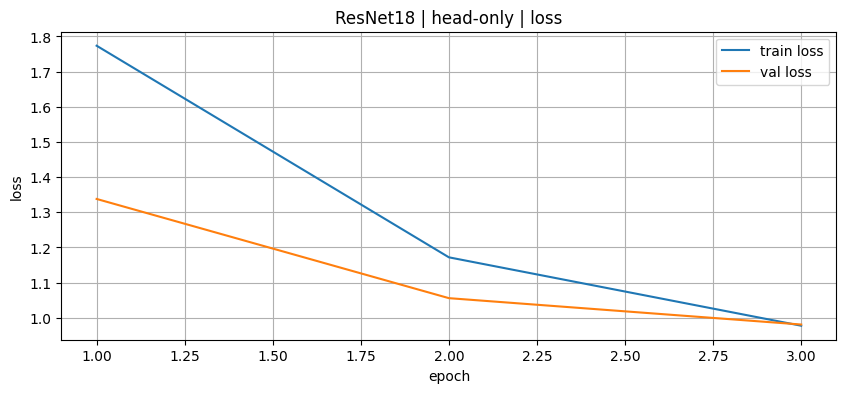

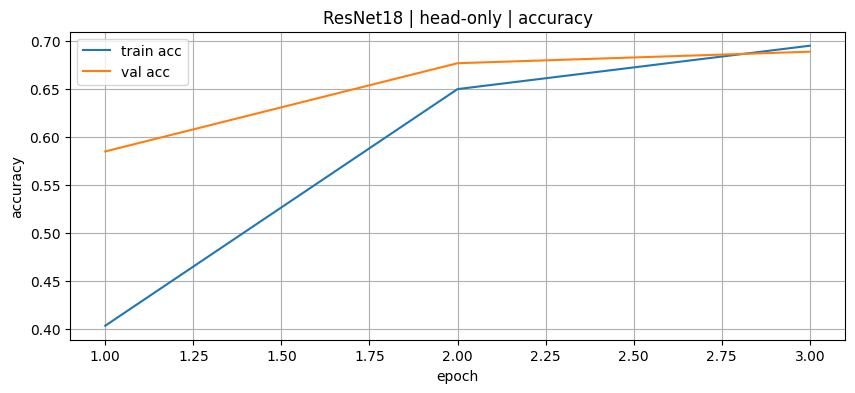

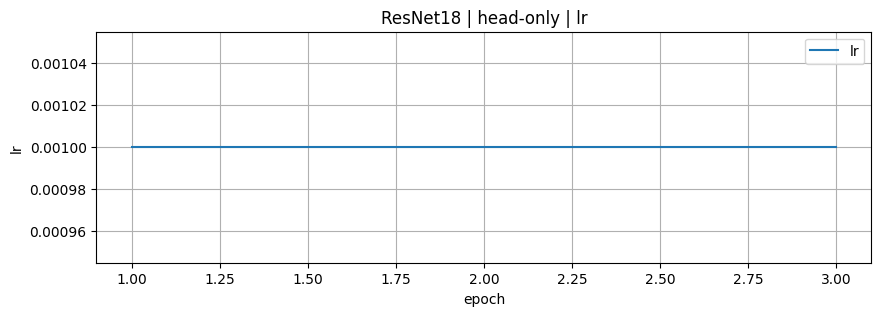

Saved C3 model to ./artifacts/best_classifier_C3.pt and updated ./artifacts/runs.csv


In [72]:

criterion = nn.CrossEntropyLoss()

model_head = build_resnet18(num_classes=10, weights_arg=weights).to(DEVICE)

# freeze всё
set_requires_grad(model_head, False)
# размораживаем только голову
set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit(model_head, train_loader, val_loader, optimizer_head, criterion, epochs=EPOCHS_HEAD, verbose=True)
plot_history(hist_head, title="ResNet18 | head-only")
# Сохранение результатов и модели (C3 head-only)
import os, json, pandas as pd
os.makedirs('./artifacts', exist_ok=True)
best_val_acc_head = float(np.nanmax(hist_head["val_acc"])) if len(hist_head["val_acc"]) else float("nan")
model_path = './artifacts/best_classifier_C3.pt'
torch.save(model_head.state_dict(), model_path)
config = {"dataset": "STL10", "seed": int(RANDOM_STATE), "model_summary": "ResNet18-head-only", "optimizer": "Adam", "lr": 1e-3, "epochs_trained": int(EPOCHS_HEAD), "best_val_accuracy": float(best_val_acc_head)}
with open('./artifacts/best_classifier_config_C3.json', 'w') as f: json.dump(config, f, indent=2)
runs_path = './artifacts/runs.csv'
row = { 'experiment_id': 'C3', 'task': 'classification', 'dataset': 'STL10', 'seed': int(RANDOM_STATE), 'model_summary': 'ResNet18-head-only', 'optimizer': 'Adam', 'lr': '1e-3', 'epochs_trained': int(EPOCHS_HEAD), 'best_val_accuracy': float(best_val_acc_head), 'precision': '', 'recall': '', 'mean_iou': '', 'notes': '' }
if os.path.exists(runs_path):
    df_runs = pd.read_csv(runs_path)
    df_runs = df_runs[df_runs['experiment_id'] != 'C3']
    df_runs = pd.concat([df_runs, pd.DataFrame([row])], ignore_index=True)
else:
    df_runs = pd.DataFrame([row])
df_runs.to_csv(runs_path, index=False)
print('Saved C3 model to', model_path, 'and updated', runs_path)

Trainable params (layer4+fc): 8398858

Phase 2: fine-tuning layer4 + fc


c:\Users\Пётр\Desktop\IAIapp\IAI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/3 | lr 1.00e-04 | train loss 0.2395, acc 0.917 | val loss 0.4966, acc 0.836 | 219.2s
Epoch 02/3 | lr 1.00e-04 | train loss 0.1808, acc 0.936 | val loss 0.5208, acc 0.824 | 226.4s
Epoch 03/3 | lr 1.00e-04 | train loss 0.1260, acc 0.960 | val loss 0.4941, acc 0.831 | 238.0s


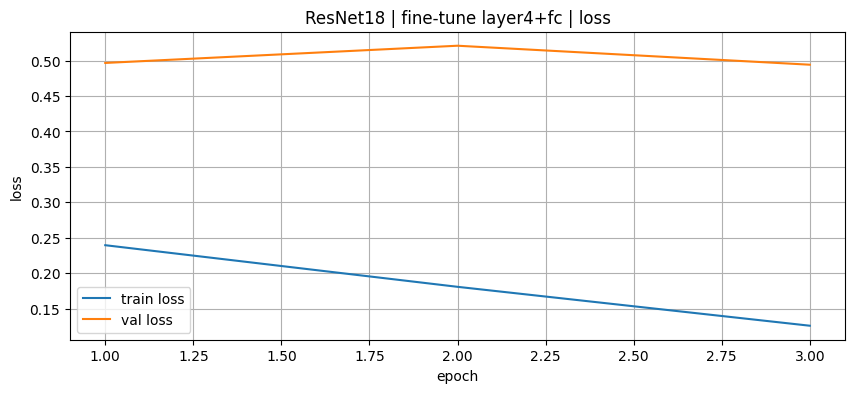

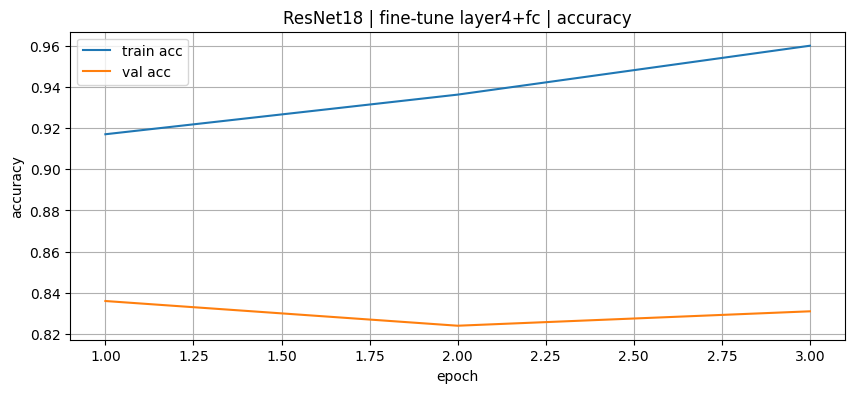

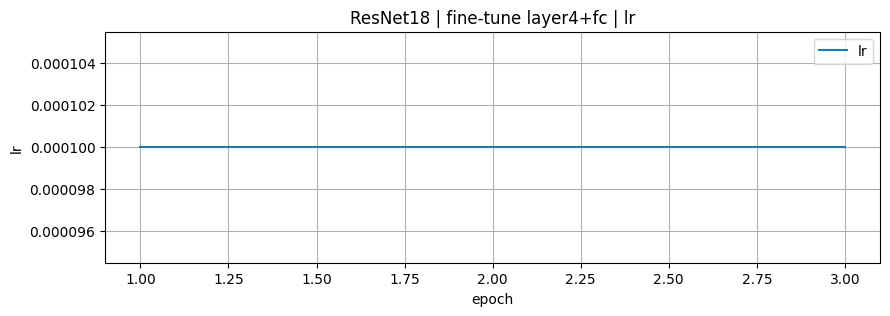

Saved C4 model to ./artifacts/best_classifier_C4.pt and updated ./artifacts/runs.csv


: 

In [ ]:
# размораживаем layer4 и fc
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_head))

# param groups: backbone меньше, head больше
params = [
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = fit(model_head, train_loader, val_loader, optimizer_ft, criterion, epochs=EPOCHS_FT, verbose=True)
plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc")
# Сохранение результатов и модели (C4 fine-tune)
import os, json, pandas as pd
os.makedirs('./artifacts', exist_ok=True)
best_val_acc_ft = float(np.nanmax(hist_ft["val_acc"])) if len(hist_ft["val_acc"]) else float("nan")
model_path = './artifacts/best_classifier_C4.pt'
torch.save(model_head.state_dict(), model_path)

# Сохраняем конфигурацию модели + трансформы (для воспроизводимости)
config = {
    "dataset": "STL10",
    "seed": int(RANDOM_STATE),
    "model_summary": "ResNet18-layer4+fc",
    "optimizer": "Adam",
    "lr": "1e-4/1e-3",
    "epochs_trained": int(EPOCHS_HEAD + EPOCHS_FT),
    "best_val_accuracy": float(best_val_acc_ft),
    "transforms": {
        "preprocess": {
            "resize": [IMG_SIZE, IMG_SIZE],
            "to_tensor": True,
            "normalize": {
                "mean": list(mean),
                "std": list(std)
            }
        },
        "augmentation": {
            "train": [
                {"RandomResizedCrop": {"size": IMG_SIZE, "scale": [0.08, 1.0], "ratio": [0.75, 1.333]}},
                {"RandomHorizontalFlip": {"p": 0.5}},
                {"ColorJitter": {"brightness": 0.2, "contrast": 0.2, "saturation": 0.2, "hue": 0.02}}
            ],
            "val": [
                {"Resize": {"size": [IMG_SIZE + 32, IMG_SIZE + 32]}},
                {"CenterCrop": {"size": IMG_SIZE}}
            ]
        }
    }
}

with open('./artifacts/best_classifier_config_C4.json', 'w') as f:
    json.dump(config, f, indent=2)

runs_path = './artifacts/runs.csv'
row = { 'experiment_id': 'C4', 'task': 'classification', 'dataset': 'STL10', 'seed': int(RANDOM_STATE), 'model_summary': 'ResNet18-layer4+fc', 'optimizer': 'Adam', 'lr': '1e-4/1e-3', 'epochs_trained': int(EPOCHS_HEAD + EPOCHS_FT), 'best_val_accuracy': float(best_val_acc_ft), 'precision': '', 'recall': '', 'mean_iou': '', 'notes': '' }
if os.path.exists(runs_path):
    df_runs = pd.read_csv(runs_path)
    df_runs = df_runs[df_runs['experiment_id'] != 'C4']
    df_runs = pd.concat([df_runs, pd.DataFrame([row])], ignore_index=True)
else:
    df_runs = pd.DataFrame([row])
df_runs.to_csv(runs_path, index=False)
print('Saved C4 model to', model_path, 'and updated', runs_path)


In [74]:
import os
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch

print("torch:", torch.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch: 2.10.0+cpu
device: cpu


In [75]:
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = False
    n_show: int = 4                 # сколько примеров визуализируем
    score_thr: float = 0.3          # порог по score для предсказаний
    iou_thr: float = 0.5            # порог IoU для TP/FP/FN
    model_name: str = "fasterrcnn_mobilenet_v3_large_fpn"  # быстрее на CPU
    # варианты: "fasterrcnn_resnet50_fpn_v2", "retinanet_resnet50_fpn_v2", ...

cfg = RunConfig()

In [ ]:
import os

# 3) Данные: PASCAL VOC 2012 (download/unzip при необходимости)

VOC_URL = "http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar"

def ensure_voc(root: str) -> str:
    '''
    Гарантируем наличие папки root/VOCdevkit/VOC2012.
    Возвращаем путь к VOC2012.
    '''
    voc_root = os.path.join(root, "VOCdevkit", "VOC2012")
    if os.path.isdir(voc_root):
        return voc_root

    os.makedirs(root, exist_ok=True)

    try:
        from torchvision.datasets.utils import download_and_extract_archive

        print("Downloading PASCAL VOC 2012 to:", root)
        download_and_extract_archive(
            VOC_URL,
            download_root=root,
            filename="VOCtrainval_11-May-2012.tar",
            remove_finished=False
        )

        if not os.path.isdir(voc_root):
            raise FileNotFoundError(
                "После распаковки не найдено VOCdevkit/VOC2012/. "
                "Проверьте содержимое папки data_dir."
            )

        return voc_root

    except Exception as e:
        print("Не удалось автоматически скачать датасет PASCAL VOC 2012.")
        print("Ошибка:", repr(e))
        print("\nВариант вручную:")
        print(f"1) скачайте {VOC_URL}")
        print(f"2) распакуйте так, чтобы было: {voc_root}/JPEGImages, {voc_root}/Annotations, {voc_root}/ImageSets")
        raise

voc_root = ensure_voc(cfg.data_dir)
voc_root

'./data\\VOCdevkit\\VOC2012'

In [77]:
from PIL import Image
import os
import xml.etree.ElementTree as ET
from typing import List

import numpy as np
import torch

try:
    from torchvision.transforms import ToTensor
    _to_tensor = ToTensor()
except Exception as e:
    raise RuntimeError("Нужен torchvision для ToTensor().") from e

# Pascal VOC 20 classes (no background)
VOC_CLASSES = [
    "aeroplane",
    "bicycle",
    "bird",
    "boat",
    "bottle",
    "bus",
    "car",
    "cat",
    "chair",
    "cow",
    "diningtable",
    "dog",
    "horse",
    "motorbike",
    "person",
    "pottedplant",
    "sheep",
    "sofa",
    "train",
    "tvmonitor",
]

CLASS_TO_IDX = {name: i + 1 for i, name in enumerate(VOC_CLASSES)}  # start labels at 1


class PASCALVOCDataset(torch.utils.data.Dataset):
    """Dataset for PASCAL VOC detection (reads JPEGImages + Annotations).

    Returns (image_tensor, target) where target is a dict with keys:
      - boxes: FloatTensor[N, 4] in (xmin, ymin, xmax, ymax) format
      - labels: Int64Tensor[N]
      - image_id: Int64Tensor[1]
      - area: FloatTensor[N]
      - iscrowd: Int64Tensor[N]

    Parameters
    - root: path to a VOC folder, e.g. path/to/VOCdevkit/VOC2012
    - keep_difficult: whether to keep objects marked as difficult
    """

    def __init__(self, root: str, keep_difficult: bool = False):
        self.root = root
        self.img_dir = os.path.join(root, "JPEGImages")
        self.ann_dir = os.path.join(root, "Annotations")

        if not os.path.isdir(self.img_dir) or not os.path.isdir(self.ann_dir):
            raise RuntimeError("Похоже, структура PASCAL VOC повреждена или не распакована полностью.")

        self.ids = sorted([os.path.splitext(f)[0] for f in os.listdir(self.img_dir)
                           if f.lower().endswith((".jpg", ".jpeg", ".png"))])

        if len(self.ids) == 0:
            raise RuntimeError("Не найдено изображений в папке JPEGImages.")

        self.keep_difficult = keep_difficult

    def __len__(self) -> int:
        return len(self.ids)

    def __getitem__(self, idx: int):
        img_id = self.ids[idx]
        # image path (try common extensions)
        img_path = None
        for ext in (".jpg", ".jpeg", ".png"):
            p = os.path.join(self.img_dir, img_id + ext)
            if os.path.exists(p):
                img_path = p
                break
        if img_path is None:
            raise FileNotFoundError(f"Image for id {img_id} not found in JPEGImages")

        ann_path = os.path.join(self.ann_dir, img_id + ".xml")
        if not os.path.exists(ann_path):
            raise FileNotFoundError(f"Annotation for id {img_id} not found in Annotations")

        img = Image.open(img_path).convert("RGB")

        boxes: List[List[float]] = []
        labels: List[int] = []
        iscrowd: List[int] = []

        tree = ET.parse(ann_path)
        root = tree.getroot()

        for obj in root.findall("object"):
            difficult = int(obj.findtext("difficult", default="0"))
            if difficult == 1 and not self.keep_difficult:
                continue

            name = obj.findtext("name")
            if name not in CLASS_TO_IDX:
                # skip unknown class names
                continue

            bbox = obj.find("bndbox")
            xmin = float(bbox.findtext("xmin"))
            ymin = float(bbox.findtext("ymin"))
            xmax = float(bbox.findtext("xmax"))
            ymax = float(bbox.findtext("ymax"))

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(CLASS_TO_IDX[name])
            # use `difficult` flag as iscrowd proxy (VOC doesn't have iscrowd)
            iscrowd.append(difficult)

        if len(boxes) == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
            iscrowd_t = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
            labels_t = torch.as_tensor(labels, dtype=torch.int64)
            iscrowd_t = torch.as_tensor(iscrowd, dtype=torch.int64)
            area = (boxes_t[:, 3] - boxes_t[:, 1]) * (boxes_t[:, 2] - boxes_t[:, 0])

        image_id = torch.tensor([idx], dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd_t,
        }

        img_t = _to_tensor(img)
        return img_t, target


def collate_fn(batch):
    return tuple(zip(*batch))





In [78]:


# Detected VOC in workspace
voc_root = r"c:\Users\Пётр\Desktop\IAIapp\IAI\homeworks\HW10-11\data\VOCdevkit\VOC2012"

try:
    dataset = PASCALVOCDataset(voc_root)
    print('dataset length =', len(dataset))
    img_t, target = dataset[0]
    print('image tensor shape =', img_t.shape)
    print('target keys =', list(target.keys()))
    print('target shapes:', {k: (v.shape if hasattr(v, 'shape') else type(v)) for k, v in target.items()})
except Exception as e:
    print('Error while creating/using dataset:', e)


dataset length = 193
image tensor shape = torch.Size([3, 500, 486])
target keys = ['boxes', 'labels', 'image_id', 'area', 'iscrowd']
target shapes: {'boxes': torch.Size([1, 4]), 'labels': torch.Size([1]), 'image_id': torch.Size([1]), 'area': torch.Size([1]), 'iscrowd': torch.Size([1])}


In [79]:
def get_detection_model(name: str):
    import torchvision
    from torchvision.models.detection import (
        fasterrcnn_resnet50_fpn_v2,
        fasterrcnn_mobilenet_v3_large_fpn,
        retinanet_resnet50_fpn_v2,
        FasterRCNN_ResNet50_FPN_V2_Weights,
        FasterRCNN_MobileNet_V3_Large_FPN_Weights,
        RetinaNet_ResNet50_FPN_V2_Weights,
    )

    name = name.strip()

    if name == "fasterrcnn_resnet50_fpn_v2":
        weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
        model = fasterrcnn_resnet50_fpn_v2(weights=weights)
    elif name == "retinanet_resnet50_fpn_v2":
        weights = RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT
        model = retinanet_resnet50_fpn_v2(weights=weights)
    elif name == "fasterrcnn_mobilenet_v3_large_fpn":
        weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
        model = fasterrcnn_mobilenet_v3_large_fpn(weights=weights)
    else:
        raise ValueError(f"Unknown model_name: {name}")

    categories = weights.meta.get("categories", None)
    person_label = None
    if categories and "person" in categories:
        person_label = categories.index("person")  # у COCO обычно 1

    model.eval()
    return model, weights, categories, person_label

model, weights, categories, person_label = get_detection_model(cfg.model_name)
model.to(DEVICE)
print("model:", cfg.model_name)
print("person_label:", person_label)

model: fasterrcnn_mobilenet_v3_large_fpn
person_label: 1


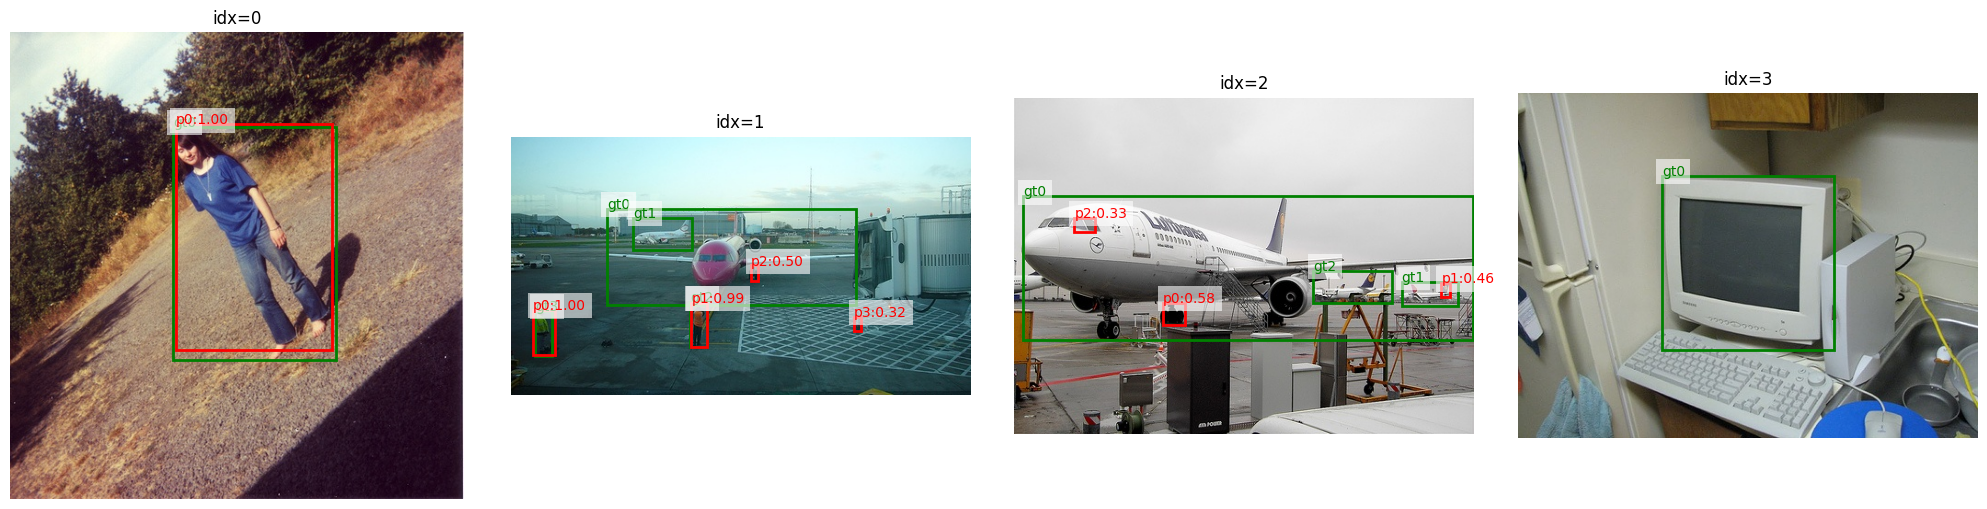

In [80]:
def draw_boxes(ax, boxes, color="r", linewidth=2, text=None):
    import matplotlib.patches as patches
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in b]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=linewidth, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        if text is not None:
            ax.text(x1, y1, text(i), color=color, fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

@torch.no_grad()
def predict_one(img_t: torch.Tensor) -> Dict[str, torch.Tensor]:
    out = model([img_t.to(DEVICE)])[0]
    out = {k: v.detach().cpu() for k, v in out.items()}
    return out

def filter_preds(pred: Dict[str, torch.Tensor], score_thr: float, person_label: Optional[int]) -> Dict[str, torch.Tensor]:
    keep = pred["scores"] >= score_thr
    if person_label is not None and "labels" in pred:
        keep = keep & (pred["labels"] == int(person_label))
    return {k: v[keep] for k, v in pred.items()}

# Покажем несколько примеров
n = min(cfg.n_show, len(dataset))
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]

for i in range(n):
    img_t, target = dataset[i]
    pred = predict_one(img_t)
    pred_f = filter_preds(pred, cfg.score_thr, person_label)

    img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    ax = axes[i]
    ax.imshow(img_np)
    ax.set_title(f"idx={i}")
    ax.axis("off")

    # GT - зелёный, Pred - красный
    draw_boxes(ax, target["boxes"], color="g", linewidth=2, text=lambda j: f"gt{j}")
    draw_boxes(ax, pred_f["boxes"], color="r", linewidth=2, text=lambda j: f"p{j}:{pred_f['scores'][j]:.2f}")

plt.tight_layout()
plt.show()

In [81]:
def box_iou_matrix(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    '''
    boxes: [N,4] and [M,4] in (x1,y1,x2,y2), returns [N,M]
    '''
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    x1 = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    union = area1[:, None] + area2[None, :] - inter + 1e-9
    return inter / union

def match_greedy(pred_boxes: torch.Tensor, pred_scores: torch.Tensor, gt_boxes: torch.Tensor, iou_thr: float) -> Tuple[int, int, int, float]:
    '''
    Жадный матчинг: идём по pred по убыванию score, матчим к лучшему ещё не занятому GT.
    Возвращаем TP, FP, FN и средний IoU по матчам.
    '''
    if pred_boxes.numel() == 0:
        tp, fp, fn = 0, 0, int(gt_boxes.shape[0])
        return tp, fp, fn, float("nan")

    order = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[order]
    pred_scores = pred_scores[order]

    iou = box_iou_matrix(pred_boxes, gt_boxes)  # [P,G]
    gt_used = torch.zeros((gt_boxes.shape[0],), dtype=torch.bool)

    tp = 0
    fp = 0
    ious = []

    for p in range(pred_boxes.shape[0]):
        if gt_boxes.shape[0] == 0:
            fp += 1
            continue
        best_iou, best_j = torch.max(iou[p], dim=0)
        best_iou = float(best_iou.item())
        best_j = int(best_j.item())

        if best_iou >= iou_thr and not gt_used[best_j]:
            tp += 1
            gt_used[best_j] = True
            ious.append(best_iou)
        else:
            fp += 1

    fn = int((~gt_used).sum().item())
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")
    return tp, fp, fn, mean_iou

def evaluate_subset(indices: List[int]) -> Dict[str, float]:
    tps = fps = fns = 0
    ious = []
    for idx in indices:
        img_t, target = dataset[idx]
        pred = predict_one(img_t)
        pred_f = filter_preds(pred, cfg.score_thr, person_label)

        tp, fp, fn, miou = match_greedy(pred_f["boxes"], pred_f["scores"], target["boxes"], cfg.iou_thr)
        tps += tp
        fps += fp
        fns += fn
        if math.isfinite(miou):
            ious.append(miou)

    precision = tps / (tps + fps + 1e-9)
    recall = tps / (tps + fns + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")

    return {
        "TP": float(tps),
        "FP": float(fps),
        "FN": float(fns),
        "precision@IoU": precision,
        "recall@IoU": recall,
        "F1@IoU": f1,
        "mean_IoU_matched": mean_iou,
    }

# Оцениваем небольшое подмножество (быстро), либо больше (если fast_mode=False)
if cfg.fast_mode:
    eval_indices = list(range(min(20, len(dataset))))
else:
    eval_indices = list(range(len(dataset)))

metrics = evaluate_subset(eval_indices)
metrics

{'TP': 141.0,
 'FP': 202.0,
 'FN': 298.0,
 'precision@IoU': 0.4110787171999677,
 'recall@IoU': 0.32118451024983785,
 'F1@IoU': 0.36061381024830097,
 'mean_IoU_matched': 0.843461464145483}

In [82]:
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = False
    n_show: int = 4                 # сколько примеров визуализируем
    score_thr: float = 0.7         # порог по score для предсказаний
    iou_thr: float = 0.5            # порог IoU для TP/FP/FN
    model_name: str = "fasterrcnn_mobilenet_v3_large_fpn"  # быстрее на CPU
    # варианты: "fasterrcnn_resnet50_fpn_v2", "retinanet_resnet50_fpn_v2", ...

cfg = RunConfig()

In [83]:
import os

# 3) Данные: PASCAL VOC 2012 (download/unzip при необходимости)

VOC_URL = "http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar"

def ensure_voc(root: str) -> str:
    '''
    Гарантируем наличие папки root/VOCdevkit/VOC2012.
    Возвращаем путь к VOC2012.
    '''
    voc_root = os.path.join(root, "VOCdevkit", "VOC2012")
    if os.path.isdir(voc_root):
        return voc_root

    os.makedirs(root, exist_ok=True)

    try:
        from torchvision.datasets.utils import download_and_extract_archive

        print("Downloading PASCAL VOC 2012 to:", root)
        download_and_extract_archive(
            VOC_URL,
            download_root=root,
            filename="VOCtrainval_11-May-2012.tar",
            remove_finished=False
        )

        if not os.path.isdir(voc_root):
            raise FileNotFoundError(
                "После распаковки не найдено VOCdevkit/VOC2012/. "
                "Проверьте содержимое папки data_dir."
            )

        return voc_root

    except Exception as e:
        print("Не удалось автоматически скачать датасет PASCAL VOC 2012.")
        print("Ошибка:", repr(e))
        print("\nВариант вручную:")
        print(f"1) скачайте {VOC_URL}")
        print(f"2) распакуйте так, чтобы было: {voc_root}/JPEGImages, {voc_root}/Annotations, {voc_root}/ImageSets")
        raise

voc_root = ensure_voc(cfg.data_dir)
voc_root

'./data\\VOCdevkit\\VOC2012'

In [84]:
from PIL import Image
import os
import xml.etree.ElementTree as ET
from typing import List

import numpy as np
import torch

try:
    from torchvision.transforms import ToTensor
    _to_tensor = ToTensor()
except Exception as e:
    raise RuntimeError("Нужен torchvision для ToTensor().") from e

# Pascal VOC 20 classes (no background)
VOC_CLASSES = [
    "aeroplane",
    "bicycle",
    "bird",
    "boat",
    "bottle",
    "bus",
    "car",
    "cat",
    "chair",
    "cow",
    "diningtable",
    "dog",
    "horse",
    "motorbike",
    "person",
    "pottedplant",
    "sheep",
    "sofa",
    "train",
    "tvmonitor",
]

CLASS_TO_IDX = {name: i + 1 for i, name in enumerate(VOC_CLASSES)}  # start labels at 1


class PASCALVOCDataset(torch.utils.data.Dataset):
    """Dataset for PASCAL VOC detection (reads JPEGImages + Annotations).

    Returns (image_tensor, target) where target is a dict with keys:
      - boxes: FloatTensor[N, 4] in (xmin, ymin, xmax, ymax) format
      - labels: Int64Tensor[N]
      - image_id: Int64Tensor[1]
      - area: FloatTensor[N]
      - iscrowd: Int64Tensor[N]

    Parameters
    - root: path to a VOC folder, e.g. path/to/VOCdevkit/VOC2012
    - keep_difficult: whether to keep objects marked as difficult
    """

    def __init__(self, root: str, keep_difficult: bool = False):
        self.root = root
        self.img_dir = os.path.join(root, "JPEGImages")
        self.ann_dir = os.path.join(root, "Annotations")

        if not os.path.isdir(self.img_dir) or not os.path.isdir(self.ann_dir):
            raise RuntimeError("Похоже, структура PASCAL VOC повреждена или не распакована полностью.")

        self.ids = sorted([os.path.splitext(f)[0] for f in os.listdir(self.img_dir)
                           if f.lower().endswith((".jpg", ".jpeg", ".png"))])

        if len(self.ids) == 0:
            raise RuntimeError("Не найдено изображений в папке JPEGImages.")

        self.keep_difficult = keep_difficult

    def __len__(self) -> int:
        return len(self.ids)

    def __getitem__(self, idx: int):
        img_id = self.ids[idx]
        # image path (try common extensions)
        img_path = None
        for ext in (".jpg", ".jpeg", ".png"):
            p = os.path.join(self.img_dir, img_id + ext)
            if os.path.exists(p):
                img_path = p
                break
        if img_path is None:
            raise FileNotFoundError(f"Image for id {img_id} not found in JPEGImages")

        ann_path = os.path.join(self.ann_dir, img_id + ".xml")
        if not os.path.exists(ann_path):
            raise FileNotFoundError(f"Annotation for id {img_id} not found in Annotations")

        img = Image.open(img_path).convert("RGB")

        boxes: List[List[float]] = []
        labels: List[int] = []
        iscrowd: List[int] = []

        tree = ET.parse(ann_path)
        root = tree.getroot()

        for obj in root.findall("object"):
            difficult = int(obj.findtext("difficult", default="0"))
            if difficult == 1 and not self.keep_difficult:
                continue

            name = obj.findtext("name")
            if name not in CLASS_TO_IDX:
                # skip unknown class names
                continue

            bbox = obj.find("bndbox")
            xmin = float(bbox.findtext("xmin"))
            ymin = float(bbox.findtext("ymin"))
            xmax = float(bbox.findtext("xmax"))
            ymax = float(bbox.findtext("ymax"))

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(CLASS_TO_IDX[name])
            # use `difficult` flag as iscrowd proxy (VOC doesn't have iscrowd)
            iscrowd.append(difficult)

        if len(boxes) == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
            iscrowd_t = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
            labels_t = torch.as_tensor(labels, dtype=torch.int64)
            iscrowd_t = torch.as_tensor(iscrowd, dtype=torch.int64)
            area = (boxes_t[:, 3] - boxes_t[:, 1]) * (boxes_t[:, 2] - boxes_t[:, 0])

        image_id = torch.tensor([idx], dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd_t,
        }

        img_t = _to_tensor(img)
        return img_t, target


def collate_fn(batch):
    return tuple(zip(*batch))





In [85]:


# Detected VOC in workspace
voc_root = r"c:\Users\Пётр\Desktop\IAIapp\IAI\homeworks\HW10-11\data\VOCdevkit\VOC2012"

try:
    dataset = PASCALVOCDataset(voc_root)
    print('dataset length =', len(dataset))
    img_t, target = dataset[0]
    print('image tensor shape =', img_t.shape)
    print('target keys =', list(target.keys()))
    print('target shapes:', {k: (v.shape if hasattr(v, 'shape') else type(v)) for k, v in target.items()})
except Exception as e:
    print('Error while creating/using dataset:', e)


dataset length = 193
image tensor shape = torch.Size([3, 500, 486])
target keys = ['boxes', 'labels', 'image_id', 'area', 'iscrowd']
target shapes: {'boxes': torch.Size([1, 4]), 'labels': torch.Size([1]), 'image_id': torch.Size([1]), 'area': torch.Size([1]), 'iscrowd': torch.Size([1])}


In [86]:
def get_detection_model(name: str):
    import torchvision
    from torchvision.models.detection import (
        fasterrcnn_resnet50_fpn_v2,
        fasterrcnn_mobilenet_v3_large_fpn,
        retinanet_resnet50_fpn_v2,
        FasterRCNN_ResNet50_FPN_V2_Weights,
        FasterRCNN_MobileNet_V3_Large_FPN_Weights,
        RetinaNet_ResNet50_FPN_V2_Weights,
    )

    name = name.strip()

    if name == "fasterrcnn_resnet50_fpn_v2":
        weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
        model = fasterrcnn_resnet50_fpn_v2(weights=weights)
    elif name == "retinanet_resnet50_fpn_v2":
        weights = RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT
        model = retinanet_resnet50_fpn_v2(weights=weights)
    elif name == "fasterrcnn_mobilenet_v3_large_fpn":
        weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
        model = fasterrcnn_mobilenet_v3_large_fpn(weights=weights)
    else:
        raise ValueError(f"Unknown model_name: {name}")

    categories = weights.meta.get("categories", None)
    person_label = None
    if categories and "person" in categories:
        person_label = categories.index("person")  # у COCO обычно 1

    model.eval()
    return model, weights, categories, person_label

model, weights, categories, person_label = get_detection_model(cfg.model_name)
model.to(DEVICE)
print("model:", cfg.model_name)
print("person_label:", person_label)

model: fasterrcnn_mobilenet_v3_large_fpn
person_label: 1


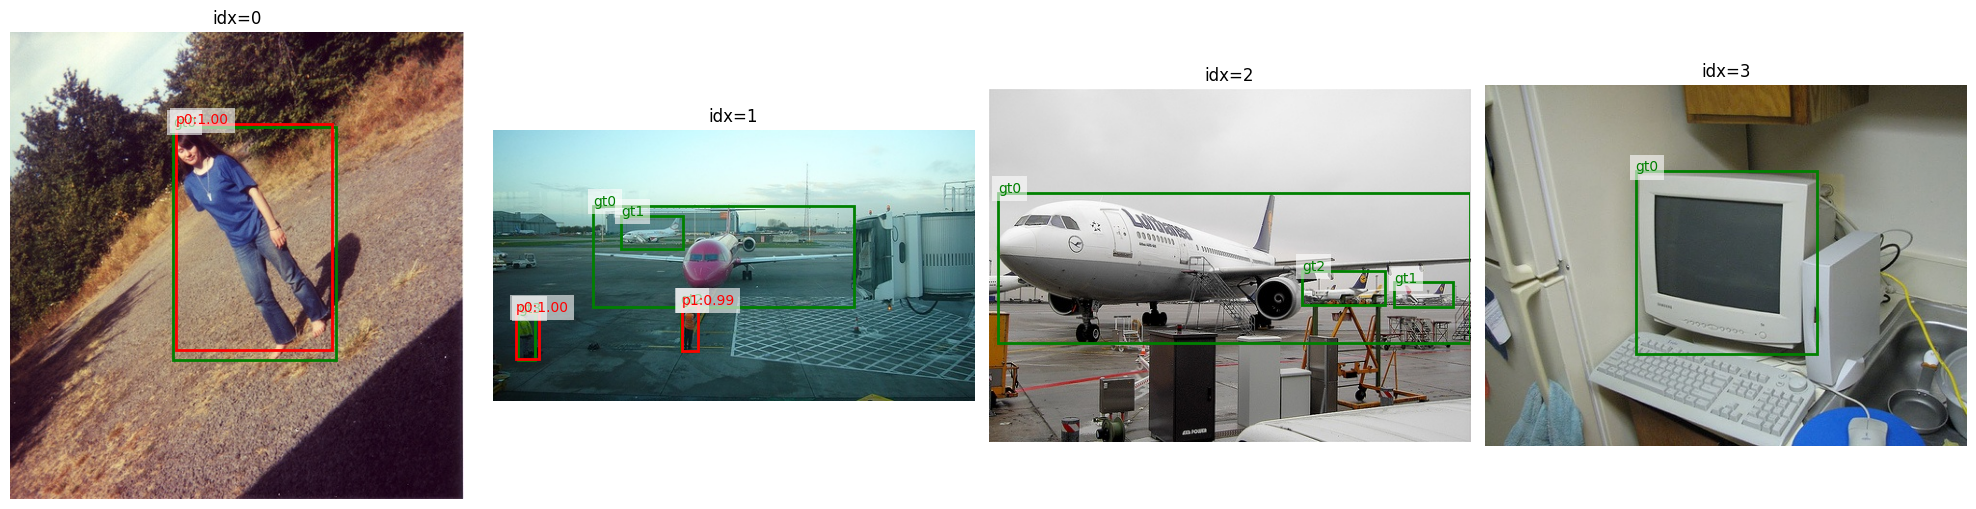

In [87]:
def draw_boxes(ax, boxes, color="r", linewidth=2, text=None):
    import matplotlib.patches as patches
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in b]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=linewidth, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        if text is not None:
            ax.text(x1, y1, text(i), color=color, fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

@torch.no_grad()
def predict_one(img_t: torch.Tensor) -> Dict[str, torch.Tensor]:
    out = model([img_t.to(DEVICE)])[0]
    out = {k: v.detach().cpu() for k, v in out.items()}
    return out

def filter_preds(pred: Dict[str, torch.Tensor], score_thr: float, person_label: Optional[int]) -> Dict[str, torch.Tensor]:
    keep = pred["scores"] >= score_thr
    if person_label is not None and "labels" in pred:
        keep = keep & (pred["labels"] == int(person_label))
    return {k: v[keep] for k, v in pred.items()}

# Покажем несколько примеров
n = min(cfg.n_show, len(dataset))
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]

for i in range(n):
    img_t, target = dataset[i]
    pred = predict_one(img_t)
    pred_f = filter_preds(pred, cfg.score_thr, person_label)

    img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    ax = axes[i]
    ax.imshow(img_np)
    ax.set_title(f"idx={i}")
    ax.axis("off")

    # GT - зелёный, Pred - красный
    draw_boxes(ax, target["boxes"], color="g", linewidth=2, text=lambda j: f"gt{j}")
    draw_boxes(ax, pred_f["boxes"], color="r", linewidth=2, text=lambda j: f"p{j}:{pred_f['scores'][j]:.2f}")

plt.tight_layout()
plt.show()

In [88]:
def box_iou_matrix(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    '''
    boxes: [N,4] and [M,4] in (x1,y1,x2,y2), returns [N,M]
    '''
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    x1 = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    union = area1[:, None] + area2[None, :] - inter + 1e-9
    return inter / union

def match_greedy(pred_boxes: torch.Tensor, pred_scores: torch.Tensor, gt_boxes: torch.Tensor, iou_thr: float) -> Tuple[int, int, int, float]:
    '''
    Жадный матчинг: идём по pred по убыванию score, матчим к лучшему ещё не занятому GT.
    Возвращаем TP, FP, FN и средний IoU по матчам.
    '''
    if pred_boxes.numel() == 0:
        tp, fp, fn = 0, 0, int(gt_boxes.shape[0])
        return tp, fp, fn, float("nan")

    order = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[order]
    pred_scores = pred_scores[order]

    iou = box_iou_matrix(pred_boxes, gt_boxes)  # [P,G]
    gt_used = torch.zeros((gt_boxes.shape[0],), dtype=torch.bool)

    tp = 0
    fp = 0
    ious = []

    for p in range(pred_boxes.shape[0]):
        if gt_boxes.shape[0] == 0:
            fp += 1
            continue
        best_iou, best_j = torch.max(iou[p], dim=0)
        best_iou = float(best_iou.item())
        best_j = int(best_j.item())

        if best_iou >= iou_thr and not gt_used[best_j]:
            tp += 1
            gt_used[best_j] = True
            ious.append(best_iou)
        else:
            fp += 1

    fn = int((~gt_used).sum().item())
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")
    return tp, fp, fn, mean_iou

def evaluate_subset(indices: List[int]) -> Dict[str, float]:
    tps = fps = fns = 0
    ious = []
    for idx in indices:
        img_t, target = dataset[idx]
        pred = predict_one(img_t)
        pred_f = filter_preds(pred, cfg.score_thr, person_label)

        tp, fp, fn, miou = match_greedy(pred_f["boxes"], pred_f["scores"], target["boxes"], cfg.iou_thr)
        tps += tp
        fps += fp
        fns += fn
        if math.isfinite(miou):
            ious.append(miou)

    precision = tps / (tps + fps + 1e-9)
    recall = tps / (tps + fns + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")

    return {
        "TP": float(tps),
        "FP": float(fps),
        "FN": float(fns),
        "precision@IoU": precision,
        "recall@IoU": recall,
        "F1@IoU": f1,
        "mean_IoU_matched": mean_iou,
    }

# Оцениваем небольшое подмножество (быстро), либо больше (если fast_mode=False)
if cfg.fast_mode:
    eval_indices = list(range(min(20, len(dataset))))
else:
    eval_indices = list(range(len(dataset)))

metrics = evaluate_subset(eval_indices)
metrics

{'TP': 133.0,
 'FP': 59.0,
 'FN': 306.0,
 'precision@IoU': 0.6927083333297255,
 'recall@IoU': 0.3029612756257336,
 'F1@IoU': 0.4215530899080825,
 'mean_IoU_matched': 0.847040216036533}

In [89]:
# Оценка лучшей модели C4 на test и безопасное обновление ./artifacts/runs.csv
print('Run: evaluate best C4 on test and update runs.csv')
import os, tempfile, pandas as pd, json
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet18
from torch.utils.data import DataLoader

# Настройки (если уже заданы в ноутбуке, используем их)
IMG_SIZE = globals().get('IMG_SIZE', 224)
STL10_MEAN = globals().get('STL10_MEAN', (0.4467, 0.4398, 0.4067))
STL10_STD = globals().get('STL10_STD', (0.2242, 0.2215, 0.2239))
DATA_DIR = globals().get('DATA_DIR', './data')
DEVICE = globals().get('DEVICE', torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
BATCH_SIZE = globals().get('BATCH_SIZE', 64)
NUM_CLASSES = globals().get('NUM_CLASSES', 10)

# transforms для evaluation (совместимо с ноутбуком)
eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

# загружаем тестовую часть STL10
print('Loading STL10 test...')
ds_test = torchvision.datasets.STL10(root=DATA_DIR, split='test', download=True, transform=eval_tf)
test_loader = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# строим модель ResNet18 и подгоняем голову под NUM_CLASSES
model = resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# выбираем файл весов: сначала C4, затем generic best_classifier.pt
art_dir = './artifacts'
candidates = [os.path.join(art_dir, 'best_classifier_C4.pt'), os.path.join(art_dir, 'best_classifier.pt')]
model_path = next((p for p in candidates if os.path.exists(p)), None)
if model_path is None:
    raise FileNotFoundError(f'Не найден файл весов. Ищутся: {candidates}')
print('Loading weights from', model_path)
state = torch.load(model_path, map_location='cpu')
model.load_state_dict(state)
model.to(DEVICE)
model.eval()

# Используем существующую функцию evaluate, если она объявлена; иначе простая реализация
if 'evaluate' in globals():
    eval_fn = globals()['evaluate']
    test_loss, test_acc = eval_fn(model, test_loader, nn.CrossEntropyLoss())
else:
    @torch.no_grad()
    def _eval_local(m, loader):
        m.eval()
        total = correct = 0
        crit = nn.CrossEntropyLoss()
        loss_sum = 0.0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = m(x)
            loss = crit(logits, y)
            loss_sum += float(loss.item()) * y.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
        return loss_sum / total if total else float('nan'), correct / (total + 1e-12)
    test_loss, test_acc = _eval_local(model, test_loader)

print(f'Test accuracy: {test_acc:.4f}, loss: {test_loss:.4f}')

# Обновляем ./artifacts/runs.csv атомарно: записываем test_accuracy для C4 (создаём строку если нужно)
runs_path = os.path.join(art_dir, 'runs.csv')
if not os.path.exists(art_dir):
    os.makedirs(art_dir, exist_ok=True)

if os.path.exists(runs_path):
    df = pd.read_csv(runs_path)
else:
    df = pd.DataFrame(columns=['experiment_id','task','dataset','seed','model_summary','optimizer','lr','epochs_trained','best_val_accuracy','test_accuracy','precision','recall','mean_iou','notes'])

mask = df['experiment_id'] == 'C4' if 'experiment_id' in df.columns else pd.Series([False]*len(df))
if mask.any():
    df.loc[mask, 'test_accuracy'] = float(test_acc)
else:
    row = {'experiment_id':'C4','task':'classification','dataset':'STL10','seed':int(globals().get('RANDOM_STATE',42)),'model_summary':'ResNet18-layer4+fc','optimizer':'Adam','lr':'1e-4/1e-3','epochs_trained':'','best_val_accuracy':'', 'test_accuracy':float(test_acc), 'precision':'','recall':'','mean_iou':'','notes':''}
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)

# atomic write with tmp file and replace
tmp_path = None
try:
    with tempfile.NamedTemporaryFile('w', delete=False, dir=art_dir, newline='') as tmp:
        tmp_path = tmp.name
        df.to_csv(tmp.name, index=False)
    os.replace(tmp_path, runs_path)
    print('Updated', runs_path)
except PermissionError as e:
    print('PermissionError while writing runs.csv:', e)
    if tmp_path and os.path.exists(tmp_path):
        os.remove(tmp_path)
    print('Пожалуйста, закройте ./artifacts/runs.csv, если он открыт в другой программе, и запустите ячейку снова.')
except Exception as e:
    if tmp_path and os.path.exists(tmp_path):
        os.remove(tmp_path)
    raise

Run: evaluate best C4 on test and update runs.csv
Loading STL10 test...
Loading weights from ./artifacts\best_classifier_C4.pt


c:\Users\Пётр\Desktop\IAIapp\IAI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test accuracy: 0.4068, loss: 3.9338
Updated ./artifacts\runs.csv
